# Painted Wolf Optimization: prueba interactiva del repositorio oficial

Notebook tutorial para ejecutar la implementación Python publicada por
Saeid Sheikhi, revisar su salida y repetir pruebas con semillas controladas.

**Fuente:** repositorio oficial `saeidsheikhi/Painted-Wolf-Optimization`,
archivo `Python/PWO.py`.

> Este notebook importa el archivo oficial sin modificarlo. Los cálculos
> auxiliares, validaciones y visualizaciones viven aquí.

## Goal

Al finalizar podrás:

1. localizar e importar el código oficial;
2. ejecutar PWO sobre Sphere con una semilla reproducible;
3. verificar convergencia, límites y consistencia del mejor resultado;
4. visualizar la curva sin depender de librerías gráficas adicionales;
5. repetir el experimento con varias semillas;
6. reproducir manualmente una asignación de explotación.

## Setup

### 1. Localizar el repositorio oficial

La carpeta de trabajo y el repositorio del autor son hermanos:

```text
painted-wolf-optimization/
├── Painted-Wolf-Optimization/        # código oficial
└── pwo-optimizacion-estocastica/     # este proyecto
```

La celda también acepta la variable de entorno `PWO_OFFICIAL_REPO`, útil para
ejecutar una copia del notebook desde otra ubicación.

In [1]:
from contextlib import redirect_stdout
from io import StringIO
import os
from pathlib import Path
import sys

import numpy as np
from IPython.display import SVG, display


def locate_official_repo(start: Path | None = None) -> Path:
    env_path = os.environ.get("PWO_OFFICIAL_REPO")
    candidates = []
    if env_path:
        candidates.append(Path(env_path).expanduser())

    start = (start or Path.cwd()).resolve()
    for anchor in (start, *start.parents):
        candidates.extend(
            [
                anchor / "Painted-Wolf-Optimization",
                anchor.parent / "Painted-Wolf-Optimization",
            ]
        )

    for candidate in candidates:
        source = candidate / "Python" / "PWO.py"
        if source.is_file():
            return candidate.resolve()

    checked = "\n".join(f"- {path}" for path in candidates)
    raise FileNotFoundError(
        "No se encontró Python/PWO.py. Ejecuta el notebook desde el repositorio "
        "de trabajo o define PWO_OFFICIAL_REPO.\nRutas revisadas:\n" + checked
    )


OFFICIAL_REPO = locate_official_repo()
PYTHON_SOURCE = OFFICIAL_REPO / "Python"
sys.path.insert(0, str(PYTHON_SOURCE))

from PWO import PWO

print(f"Repositorio oficial: {OFFICIAL_REPO.name}")
print("Implementación cargada: Python/PWO.py")

Repositorio oficial: Painted-Wolf-Optimization
Implementación cargada: Python/PWO.py


### 2. Definir funciones objetivo y parámetros

La prueba base replica la configuración usada en el informe de avance:
Sphere en tres dimensiones, 20 agentes, 100 iteraciones y semilla
`20260728`.

La semilla hace reproducible **la ejecución Python**. MATLAB utiliza otro
generador, por lo que la misma semilla no implica la misma trayectoria.

In [2]:
def sphere(x: np.ndarray) -> float:
    return float(np.sum(x**2))


def rastrigin(x: np.ndarray) -> float:
    dimension = x.size
    return float(10 * dimension + np.sum(x**2 - 10 * np.cos(2 * np.pi * x)))


CONFIG = {
    "seed": 20260728,
    "num_agents": 20,
    "max_iterations": 100,
    "dimension": 3,
    "lower_bound": -100.0,
    "upper_bound": 100.0,
    "objective": sphere,
    "objective_name": "Sphere",
}

CONFIG

{'seed': 20260728,
 'num_agents': 20,
 'max_iterations': 100,
 'dimension': 3,
 'lower_bound': -100.0,
 'upper_bound': 100.0,
 'objective': <function __main__.sphere(x: numpy.ndarray) -> float>,
 'objective_name': 'Sphere'}

## Steps

### 3. Ejecutar la prueba base

`PWO.py` imprime avances por consola. Se captura esa salida para mantener el
notebook legible y se muestran solamente sus últimas líneas.

In [3]:
np.random.seed(CONFIG["seed"])
captured_output = StringIO()

with redirect_stdout(captured_output):
    best_score, best_position, convergence_curve = PWO(
        CONFIG["num_agents"],
        CONFIG["max_iterations"],
        CONFIG["lower_bound"],
        CONFIG["upper_bound"],
        CONFIG["dimension"],
        CONFIG["objective"],
    )

log_lines = captured_output.getvalue().strip().splitlines()
print("\n".join(log_lines[-7:]))

   40 |  1.126617e-31
   60 |  1.422114e-51
   80 |  4.083675e-69
  100 |  2.519815e-92
---------------------------
PWO Algorithm Finished.
Best Score Found: 2.519815240595654e-92


### 4. Resumir y validar el resultado

La curva oficial almacena el mejor fitness histórico antes de cada nueva
actualización. Por eso debe ser monótona no creciente.

In [4]:
checks = {
    "curve_length_ok": convergence_curve.shape == (CONFIG["max_iterations"],),
    "curve_is_finite": bool(np.all(np.isfinite(convergence_curve))),
    "curve_is_nonincreasing": bool(np.all(np.diff(convergence_curve) <= 0)),
    "best_score_matches_curve": bool(
        np.isclose(best_score, convergence_curve[-1], rtol=1e-12, atol=0.0)
    ),
    "best_position_within_bounds": bool(
        np.all(best_position >= CONFIG["lower_bound"])
        and np.all(best_position <= CONFIG["upper_bound"])
    ),
    "objective_matches_best_score": bool(
        np.isclose(
            CONFIG["objective"](best_position),
            best_score,
            rtol=1e-10,
            atol=np.finfo(float).tiny,
        )
    ),
}

summary = {
    "objective": CONFIG["objective_name"],
    "seed": CONFIG["seed"],
    "initial_best": float(convergence_curve[0]),
    "final_best": float(best_score),
    "best_position": best_position.tolist(),
    "orders_of_magnitude_reduced": float(
        np.log10(convergence_curve[0]) - np.log10(max(best_score, np.finfo(float).tiny))
    ),
}

print("Resumen")
for key, value in summary.items():
    print(f"- {key}: {value}")

print("\nComprobaciones")
for key, value in checks.items():
    print(f"- {key}: {'OK' if value else 'FALLÓ'}")

assert all(checks.values()), "Al menos una comprobación de consistencia falló."

Resumen
- objective: Sphere
- seed: 20260728
- initial_best: 4281.396382635762
- final_best: 2.519815240595654e-92
- best_position: [9.257067486242626e-47, 8.55300335667528e-47, 9.65061444652186e-47]
- orders_of_magnitude_reduced: 95.23021673944203

Comprobaciones
- curve_length_ok: OK
- curve_is_finite: OK
- curve_is_nonincreasing: OK
- best_score_matches_curve: OK
- best_position_within_bounds: OK
- objective_matches_best_score: OK


### 5. Visualizar la convergencia

La gráfica se construye como SVG directamente en el notebook. Así la prueba
base solo necesita NumPy e IPython.

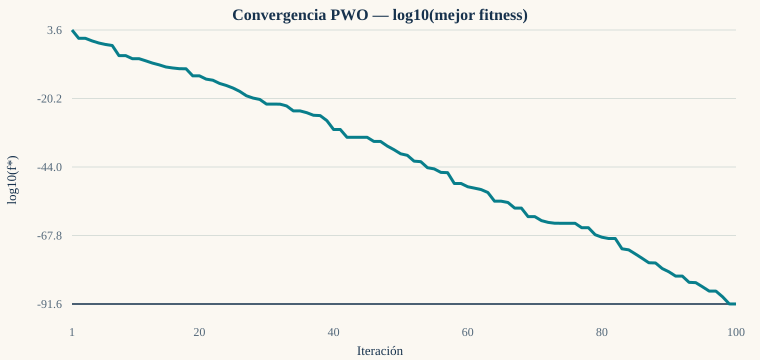

In [5]:
def convergence_svg(curve: np.ndarray, width: int = 760, height: int = 360) -> SVG:
    safe_curve = np.maximum(np.asarray(curve, dtype=float), np.finfo(float).tiny)
    log_values = np.log10(safe_curve)

    margin_left, margin_right = 72, 24
    margin_top, margin_bottom = 30, 56
    plot_width = width - margin_left - margin_right
    plot_height = height - margin_top - margin_bottom

    x_values = np.linspace(margin_left, margin_left + plot_width, log_values.size)
    y_min, y_max = float(log_values.min()), float(log_values.max())
    if np.isclose(y_min, y_max):
        y_min -= 1
        y_max += 1
    y_values = margin_top + (y_max - log_values) * plot_height / (y_max - y_min)

    points = " ".join(f"{x:.2f},{y:.2f}" for x, y in zip(x_values, y_values))
    tick_indices = np.linspace(0, log_values.size - 1, 6, dtype=int)
    x_ticks = "".join(
        f'<text x="{x_values[index]:.1f}" y="{height - 24}" '
        f'text-anchor="middle" font-size="12" fill="#526779">{index + 1}</text>'
        for index in tick_indices
    )
    y_ticks = ""
    for fraction in np.linspace(0, 1, 5):
        value = y_max - fraction * (y_max - y_min)
        y = margin_top + fraction * plot_height
        y_ticks += (
            f'<line x1="{margin_left}" y1="{y:.1f}" '
            f'x2="{margin_left + plot_width}" y2="{y:.1f}" '
            f'stroke="#d8ded9" stroke-width="1"/>'
            f'<text x="{margin_left - 10}" y="{y + 4:.1f}" '
            f'text-anchor="end" font-size="12" fill="#526779">{value:.1f}</text>'
        )

    svg = f'''
    <svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}"
         viewBox="0 0 {width} {height}">
      <rect width="100%" height="100%" fill="#fbf8f2"/>
      <text x="{width / 2}" y="20" text-anchor="middle"
            font-size="16" font-weight="700" fill="#17324d">
        Convergencia PWO — log10(mejor fitness)
      </text>
      {y_ticks}
      <line x1="{margin_left}" y1="{margin_top + plot_height}"
            x2="{margin_left + plot_width}" y2="{margin_top + plot_height}"
            stroke="#17324d" stroke-width="1.5"/>
      <polyline points="{points}" fill="none" stroke="#087e8b"
                stroke-width="3" stroke-linejoin="round"/>
      {x_ticks}
      <text x="{width / 2}" y="{height - 5}" text-anchor="middle"
            font-size="13" fill="#17324d">Iteración</text>
      <text x="16" y="{height / 2}" text-anchor="middle"
            font-size="13" fill="#17324d"
            transform="rotate(-90 16 {height / 2})">log10(f*)</text>
    </svg>
    '''
    return SVG(data=svg)


display(convergence_svg(convergence_curve))

### 6. Reproducir una asignación de explotación

Este cálculo corresponde al ruteo presentado en el informe. No reemplaza la
ejecución del algoritmo: aísla la ecuación para poder revisarla variable por
variable.

In [6]:
agent = np.array([1.01, 1.00])
alpha = np.array([1.00, 0.99])
a = 1.8
alpha_influence = 0.04 / a
rally_strength = 0.08
r1 = 0.7

A1 = 2 * a * r1 - a
A2 = rally_strength + a * A1 * alpha_influence
distance_to_alpha = np.abs(alpha - agent)
updated_agent = alpha - A2 * distance_to_alpha

route = {
    "agent_before": agent.tolist(),
    "alpha": alpha.tolist(),
    "A1": A1,
    "A2": A2,
    "distance": distance_to_alpha.tolist(),
    "agent_after": updated_agent.tolist(),
    "fitness_before": sphere(agent),
    "fitness_after": sphere(updated_agent),
}

for key, value in route.items():
    print(f"- {key}: {value}")

assert np.allclose(updated_agent, [0.998912, 0.988912])
assert np.isclose(sphere(updated_agent), 1.975772127488)

- agent_before: [1.01, 1.0]
- alpha: [1.0, 0.99]
- A1: 0.72
- A2: 0.10880000000000001
- distance: [0.010000000000000009, 0.010000000000000009]
- agent_after: [0.998912, 0.988912]
- fitness_before: 2.0201000000000002
- fitness_after: 1.9757721274880002


### 7. Medir variabilidad entre semillas

Una metaheurística no debe juzgarse por una sola ejecución. Esta celda repite
la misma configuración con tres semillas y conserva resultados acotados.

In [7]:
def run_trial(seed: int, config: dict) -> dict:
    np.random.seed(seed)
    with redirect_stdout(StringIO()):
        score, position, curve = PWO(
            config["num_agents"],
            config["max_iterations"],
            config["lower_bound"],
            config["upper_bound"],
            config["dimension"],
            config["objective"],
        )
    return {
        "seed": seed,
        "best_score": float(score),
        "best_position": position,
        "curve": curve,
    }


trial_seeds = [20260728, 20260729, 20260730]
trials = [run_trial(seed, CONFIG) for seed in trial_seeds]

print(f"{'semilla':>10} | {'mejor fitness':>16}")
print("-" * 30)
for trial in trials:
    print(f"{trial['seed']:>10} | {trial['best_score']:>16.6e}")

trial_scores = np.array([trial["best_score"] for trial in trials])
print("\nResumen de tres semillas")
print(f"- mínimo:  {trial_scores.min():.6e}")
print(f"- mediana: {np.median(trial_scores):.6e}")
print(f"- máximo:  {trial_scores.max():.6e}")

   semilla |    mejor fitness
------------------------------
  20260728 |     2.519815e-92
  20260729 |     1.057157e-89
  20260730 |     9.877497e-90

Resumen de tres semillas
- mínimo:  2.519815e-92
- mediana: 9.877497e-90
- máximo:  1.057157e-89


## Checks

La ejecución se considera válida cuando:

- el archivo importado es el `PWO.py` del repositorio oficial;
- la curva tiene una entrada por iteración;
- todos los valores son finitos;
- el mejor fitness histórico no aumenta;
- la posición final respeta los límites;
- la función objetivo evaluada en `best_position` coincide con `best_score`;
- el ruteo aislado reproduce `(0.998912, 0.988912)`.

El notebook aplica estas condiciones con `assert`, por lo que una discrepancia
detiene la ejecución.

## Next Steps

1. Cambiar `CONFIG["objective"]` por `rastrigin` y usar límites `[-5.12, 5.12]`.
2. Aumentar el conjunto de semillas antes de comparar algoritmos.
3. Registrar presupuesto de evaluaciones, no solo iteraciones.
4. Crear una variante instrumentada de PWO que devuelva rally, umbral y rama
   elegida en cada iteración.
5. Comparar las decisiones documentadas del paper con la implementación
   oficial mediante pruebas controladas.

### Equivalente MATLAB

Usa `experimentos/matlab/pwo_prueba_interactiva.m`. Está dividido con marcadores
`%%`, de modo que MATLAB permite ejecutar una sección a la vez. Si prefieres un
Live Script, ábrelo en MATLAB y usa **Save As → MATLAB Live Script (`.mlx`)**.